
# 卷积神经网络（CNN）数学原理详解

## 1. 为什么需要 CNN？

全连接网络处理图像时参数爆炸。CNN 通过**局部连接、权重共享、空间下采样**大幅减少参数量。

---

## 2. 卷积层（Convolutional Layer）

### 2.1 单通道二维互相关运算

输入 $X \in \mathbb{R}^{H \times W}$，卷积核 $K \in \mathbb{R}^{k_h \times k_w}$，输出 $Y \in \mathbb{R}^{(H-k_h+1) \times (W-k_w+1)}$：

$$
Y_{i,j} = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} X_{i+m,\, j+n} \cdot K_{m,n}
$$

### 2.2 多输入通道（$C_{\text{in}}$ 个通道）

$$
Y_{i,j} = \sum_{c=0}^{C_{\text{in}}-1} \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} X_{i+m,\, j+n,\, c} \cdot K_{m,n,c}
$$

### 2.3 多输出通道（$C_{\text{out}}$ 个卷积核）

第 $c$ 个输出通道：

$$
O_c(i,j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} \sum_{l=0}^{C_{\text{in}}-1} F(i+m,\, j+n,\, l) \cdot K(m,n,l,c)
$$

### 2.4 填充（Padding）与步幅（Stride）

输出尺寸公式：

$$
N = \frac{W - F + 2P}{S} + 1
$$

- $W$：输入尺寸
- $F$：卷积核尺寸
- $P$：填充大小
- $S$：步幅

---

## 3. 激活函数层（ReLU）

$$
\operatorname{ReLU}(x) = \max(0, x) = 
\begin{cases}
x, & x > 0 \\
0, & x \le 0
\end{cases}
$$

导数：

$$
\frac{d}{dx}\operatorname{ReLU}(x) = 
\begin{cases}
1, & x > 0 \\
0, & x \le 0
\end{cases}
$$

---

## 4. 池化层（Pooling）

### 4.1 最大池化（Max Pooling）

$$
\operatorname{MaxPool}_{(i,j)}(F) = \max_{m=0}^{p_h-1} \max_{n=0}^{p_w-1} F(i+m,\, j+n)
$$

### 4.2 平均池化（Average Pooling）

$$
\operatorname{AvgPool}_{(i,j)}(F) = \frac{1}{p_h \cdot p_w} \sum_{m=0}^{p_h-1} \sum_{n=0}^{p_w-1} F(i+m,\, j+n)
$$

---

## 5. 全连接层与输出层

展平后接矩阵乘法：

$$
\mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}
$$

Softmax 多分类：

$$
\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^{C} e^{z_j}}
$$

交叉熵损失（二分类）：

$$
L = -\left[ y \log \hat{y} + (1-y)\log(1-\hat{y}) \right]
$$

---

## 6. 反向传播（关键公式）

### 6.1 卷积层对卷积核的梯度

$$
\frac{\partial L}{\partial K} = X \ast \delta^l
$$

其中 $\ast$ 表示互相关，$\delta^l$ 为误差项。

### 6.2 误差项传递到前一层

$$
\delta^{l-1} = \delta^l \ast \operatorname{rot180}(K)
$$

### 6.3 池化层的误差传递

- **最大池化**：误差只传给前向时最大值的位置，其余位置为0。
- **平均池化**：误差等分传递给池化窗口内所有位置。

---

## 7. 总结表

| 组件 | 核心操作 | 数学表示 | 作用 |
|:---|:---|:---|:---|
| 卷积层 | 互相关 | $\displaystyle Y_{i,j} = \sum_m \sum_n X_{i+m,j+n} K_{m,n}$ | 提取局部特征 |
| 激活层 | ReLU | $\max(0,x)$ | 非线性 |
| 池化层 | 最大/平均池化 | $\max$ 或 $\frac{1}{wh}\sum$ | 降维、平移不变性 |
| 全连接层 | 矩阵乘法 | $\mathbf{z}=\mathbf{W}\mathbf{x}+\mathbf{b}$ | 分类/回归 |

---

## 8. 经典 CNN 架构

- **LeNet-5** (1998)：2 个卷积层 + 2 个池化层 + 2 个全连接层
- **AlexNet** (2012)：5 个卷积层 + 3 个全连接层 + ReLU + Dropout
- **VGG** (2014)：深度堆叠 $3\times3$ 卷积
- **ResNet** (2015)：残差连接 $F(x)+x$


## 9. CNN 的实现

##### ① 导入库和加载 MNIST

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist  # 仅用于下载数据，不用于训练

# 中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 下载 MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 归一化到 [0,1]，并增加通道维度 (n, h, w, c)
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0
X_train = X_train[..., np.newaxis]   # (60000, 28, 28, 1)
X_test  = X_test[..., np.newaxis]

# One-hot 编码
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_oh = one_hot(y_train)
y_test_oh  = one_hot(y_test)

print("训练集形状:", X_train.shape)
print("测试集形状:", X_test.shape)

训练集形状: (60000, 28, 28, 1)
测试集形状: (10000, 28, 28, 1)


In [17]:
## 数据集下载失败的情况下，清除已下载的部分缓存 
# import os
# cache_dir = os.path.expanduser("~/.keras/datasets")
# file_path = os.path.join(cache_dir, "mnist.npz")
# if os.path.exists(file_path):
#     os.remove(file_path)
#     print(f"已删除 {file_path}")
# else:
#     print("缓存文件不存在，无需删除")

##### ② 卷积层实现（im2col）

In [18]:
class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        
        # 初始化权重（He 初始化，适合 ReLU）
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))
        self.W = np.random.randn(kernel_size, kernel_size, in_channels, out_channels) * scale
        self.b = np.zeros((1, out_channels))
        
    def _im2col(self, X):
        """将输入 X (n, h, w, c) 转为矩阵 (out_h*out_w*n, k*k*c)"""
        n, h, w, c = X.shape
        k = self.kernel_size
        s = self.stride
        out_h = (h - k) // s + 1
        out_w = (w - k) // s + 1
        
        # 切出所有滑动窗口
        cols = np.zeros((n, out_h, out_w, k, k, c))
        for i in range(k):
            for j in range(k):
                cols[:, :, :, i, j, :] = X[:, i:i+out_h*s:s, j:j+out_w*s:s, :]
        
        cols = cols.transpose(0, 1, 2, 3, 4, 5).reshape(n * out_h * out_w, -1)
        return cols, out_h, out_w
    
    def forward(self, X):
        self.X = X
        n, h, w, c = X.shape
        self.cols, self.out_h, self.out_w = self._im2col(X)
        # 权重 W 形状 (k*k*c, out_channels)
        W_flat = self.W.reshape(-1, self.out_channels)
        out = np.dot(self.cols, W_flat) + self.b  # (n*out_h*out_w, out_channels)
        out = out.reshape(n, self.out_h, self.out_w, self.out_channels)
        return out
    
    def backward(self, dout):
        n = dout.shape[0]
        out_h, out_w = dout.shape[1], dout.shape[2]
        
        # dout -> dcol (梯度传递到 im2col 的输出)
        dout_flat = dout.reshape(n * out_h * out_w, -1)
        W_flat = self.W.reshape(-1, self.out_channels)
        
        # 计算 dW, db
        self.dW = np.dot(self.cols.T, dout_flat).reshape(self.W.shape)
        self.db = np.sum(dout_flat, axis=0, keepdims=True)
        
        # 计算 col 的梯度
        dcol = np.dot(dout_flat, W_flat.T)
        
        # 转换为原图梯度 (n, h, w, c)
        dX = np.zeros_like(self.X)
        n, h, w, c = dX.shape
        k = self.kernel_size
        s = self.stride
        # 逆向填充（col2im）
        dcol_reshaped = dcol.reshape(n, out_h, out_w, k, k, c)
        for i in range(k):
            for j in range(k):
                dX[:, i:i+out_h*s:s, j:j+out_w*s:s, :] += dcol_reshaped[:, :, :, i, j, :]
        return dX

##### ③ 池化层和激活函数

In [19]:
class MaxPool2D:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride
        
    def forward(self, X):
        self.X = X
        n, h, w, c = X.shape
        p = self.pool_size
        s = self.stride
        out_h = (h - p) // s + 1
        out_w = (w - p) // s + 1
        
        out = np.zeros((n, out_h, out_w, c))
        self.mask = np.zeros_like(X)  # 记录最大值位置，用于反向传播
        for i in range(out_h):
            for j in range(out_w):
                patch = X[:, i*s:i*s+p, j*s:j*s+p, :]
                out[:, i, j, :] = np.max(patch, axis=(1,2))
                # 生成掩码
                max_mask = (patch == out[:, i, j, :][:, None, None, :])
                self.mask[:, i*s:i*s+p, j*s:j*s+p, :] += max_mask
        return out
    
    def backward(self, dout):
        return dout.repeat(self.stride, axis=1).repeat(self.stride, axis=2) * self.mask

class ReLU:
    def forward(self, X):
        self.X = X
        return np.maximum(0, X)
    
    def backward(self, dout):
        dX = dout.copy()
        dX[self.X <= 0] = 0
        return dX

class SoftmaxCrossEntropy:
    """组合 Softmax + 交叉熵，数值稳定"""
    def forward(self, X, y_true):
        self.y_true = y_true
        # 减去最大值防溢出
        shift_X = X - np.max(X, axis=1, keepdims=True)
        exp_X = np.exp(shift_X)
        self.probs = exp_X / np.sum(exp_X, axis=1, keepdims=True)
        loss = -np.mean(np.sum(y_true * np.log(self.probs + 1e-8), axis=1))
        return loss
    
    def backward(self):
        return self.probs - self.y_true  # 简化梯度，除以 batch_size 在外部处理

##### ④ 全连接层

In [20]:
class FullyConnected:
    def __init__(self, input_dim, output_dim):
        scale = np.sqrt(2.0 / input_dim)
        self.W = np.random.randn(input_dim, output_dim) * scale
        self.b = np.zeros((1, output_dim))
        
    def forward(self, X):
        self.input_shape = X.shape   # ✅ 新增这一行，保存输入形状
        self.X = X.reshape(X.shape[0], -1)
        return np.dot(self.X, self.W) + self.b
    
    def backward(self, dout):
        dX = np.dot(dout, self.W.T)
        self.dW = np.dot(self.X.T, dout)
        self.db = np.sum(dout, axis=0, keepdims=True)
        return dX.reshape(self.input_shape)   # 现在可以正常 reshape 了

##### ⑤ 组装 LeNet-5

In [21]:
class LeNet5:
    def __init__(self, lr=0.01):
        self.lr = lr
        # 构建层
        self.conv1 = Conv2D(1, 6, 5)          # 28x28 -> 24x24x6
        self.relu1 = ReLU()
        self.pool1 = MaxPool2D(2, 2)          # 24x24 -> 12x12x6
        
        self.conv2 = Conv2D(6, 16, 5)         # 12x12 -> 8x8x16
        self.relu2 = ReLU()
        self.pool2 = MaxPool2D(2, 2)          # 8x8 -> 4x4x16
        
        self.fc1 = FullyConnected(4*4*16, 120)
        self.relu3 = ReLU()
        self.fc2 = FullyConnected(120, 84)
        self.relu4 = ReLU()
        self.fc3 = FullyConnected(84, 10)
        
        self.loss_fn = SoftmaxCrossEntropy()
        
    def forward(self, X, y=None):
        """前向传播，若提供 y 则返回 loss"""
        out = self.conv1.forward(X)
        out = self.relu1.forward(out)
        out = self.pool1.forward(out)
        
        out = self.conv2.forward(out)
        out = self.relu2.forward(out)
        out = self.pool2.forward(out)
        
        # 展平
        self.flatten_shape = out.shape
        out = out.reshape(out.shape[0], -1)
        
        out = self.fc1.forward(out)
        out = self.relu3.forward(out)
        out = self.fc2.forward(out)
        out = self.relu4.forward(out)
        out = self.fc3.forward(out)
        
        if y is not None:
            return self.loss_fn.forward(out, y)
        return out
    
    def backward(self):
        """执行反向传播，更新参数"""
        # 从损失开始
        dout = self.loss_fn.backward()
        
        # 全连接层反向
        dout = self.fc3.backward(dout)
        dout = self.relu4.backward(dout)
        dout = self.fc2.backward(dout)
        dout = self.relu3.backward(dout)
        dout = self.fc1.backward(dout)
        
        # 恢复形状
        dout = dout.reshape(self.flatten_shape)
        
        # 池化和卷积反向
        dout = self.pool2.backward(dout)
        dout = self.relu2.backward(dout)
        dout = self.conv2.backward(dout)
        
        dout = self.pool1.backward(dout)
        dout = self.relu1.backward(dout)
        dout = self.conv1.backward(dout)
        
        # 更新参数
        for layer in [self.conv1, self.conv2, self.fc1, self.fc2, self.fc3]:
            layer.W -= self.lr * layer.dW
            layer.b -= self.lr * layer.db
    
    def predict(self, X):
        scores = self.forward(X)
        return np.argmax(scores, axis=1)

##### ⑥ 训练循环

In [22]:
def train(model, X_train, y_train, X_val, y_val, epochs=5, batch_size=64):
    n_train = X_train.shape[0]
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(epochs):
        # 打乱数据
        perm = np.random.permutation(n_train)
        X_shuf = X_train[perm]
        y_shuf = y_train[perm]
        
        total_loss = 0
        for i in range(0, n_train, batch_size):
            X_batch = X_shuf[i:i+batch_size]
            y_batch = y_shuf[i:i+batch_size]
            
            loss = model.forward(X_batch, y_batch)
            model.backward()
            total_loss += loss * len(X_batch)
        
        avg_train_loss = total_loss / n_train
        
        # 验证
        val_loss = model.forward(X_val, y_val)
        val_pred = model.predict(X_val)
        val_acc = np.mean(val_pred == np.argmax(y_val, axis=1))
        
        train_pred = model.predict(X_train[:1000])  # 抽样测训练准确率
        train_acc = np.mean(train_pred == np.argmax(y_train[:1000], axis=1))
        
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    return train_losses, val_losses, train_accs, val_accs

# 训练（用部分数据加速演示，完整训练太慢）
X_train_small = X_train[:20000]
y_train_small = y_train_oh[:20000]
X_val = X_test[:2000]
y_val = y_test_oh[:2000]

lenet = LeNet5(lr=0.01)
history = train(lenet, X_train_small, y_train_small, X_val, y_val, epochs=6, batch_size=32)

Epoch 1/6 | Train Loss: 0.3814 | Val Loss: 0.1774 | Train Acc: 0.9670 | Val Acc: 0.9510
Epoch 2/6 | Train Loss: 0.1224 | Val Loss: 0.1772 | Train Acc: 0.9560 | Val Acc: 0.9435
Epoch 3/6 | Train Loss: 0.1009 | Val Loss: 0.1558 | Train Acc: 0.9820 | Val Acc: 0.9645
Epoch 4/6 | Train Loss: 0.0748 | Val Loss: 0.1664 | Train Acc: 0.9680 | Val Acc: 0.9615
Epoch 5/6 | Train Loss: 0.0508 | Val Loss: 0.1357 | Train Acc: 0.9850 | Val Acc: 0.9645
Epoch 6/6 | Train Loss: 0.0453 | Val Loss: 0.1178 | Train Acc: 0.9910 | Val Acc: 0.9695


##### ⑦ 可视化训练曲线

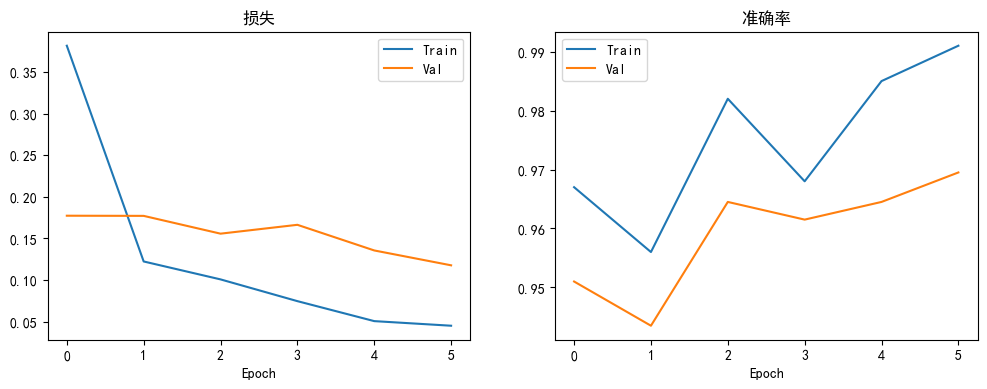

In [23]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history[0], label='Train')
plt.plot(history[1], label='Val')
plt.title('损失')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history[2], label='Train')
plt.plot(history[3], label='Val')
plt.title('准确率')
plt.xlabel('Epoch')
plt.legend()
plt.show()

##### ⑧ 查看卷积核和特征图

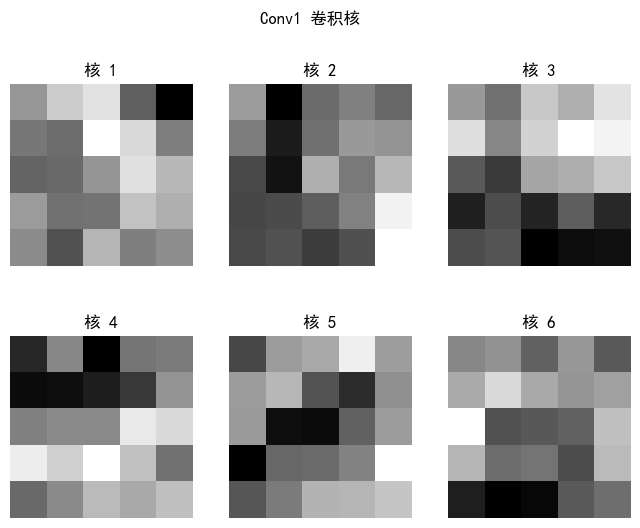

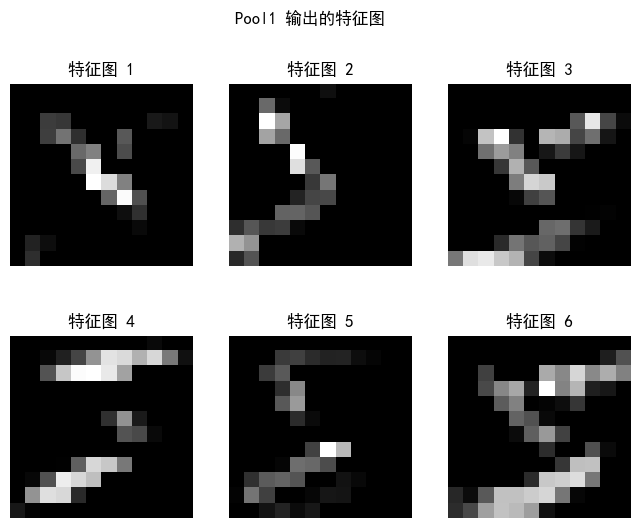

In [24]:
# 可视化第一层卷积核
fig, axes = plt.subplots(2, 3, figsize=(8, 6))
for i, ax in enumerate(axes.flat):
    kernel = lenet.conv1.W[:, :, 0, i]
    ax.imshow(kernel, cmap='gray')
    ax.set_title(f'核 {i+1}')
    ax.axis('off')
plt.suptitle('Conv1 卷积核')
plt.show()

# 可视化某个样本的特征图
sample = X_train[0:1]
out1 = lenet.conv1.forward(sample)
out1 = lenet.relu1.forward(out1)
out1 = lenet.pool1.forward(out1)
fig, axes = plt.subplots(2, 3, figsize=(8, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(out1[0, :, :, i], cmap='gray')
    ax.set_title(f'特征图 {i+1}')
    ax.axis('off')
plt.suptitle('Pool1 输出的特征图')
plt.show()

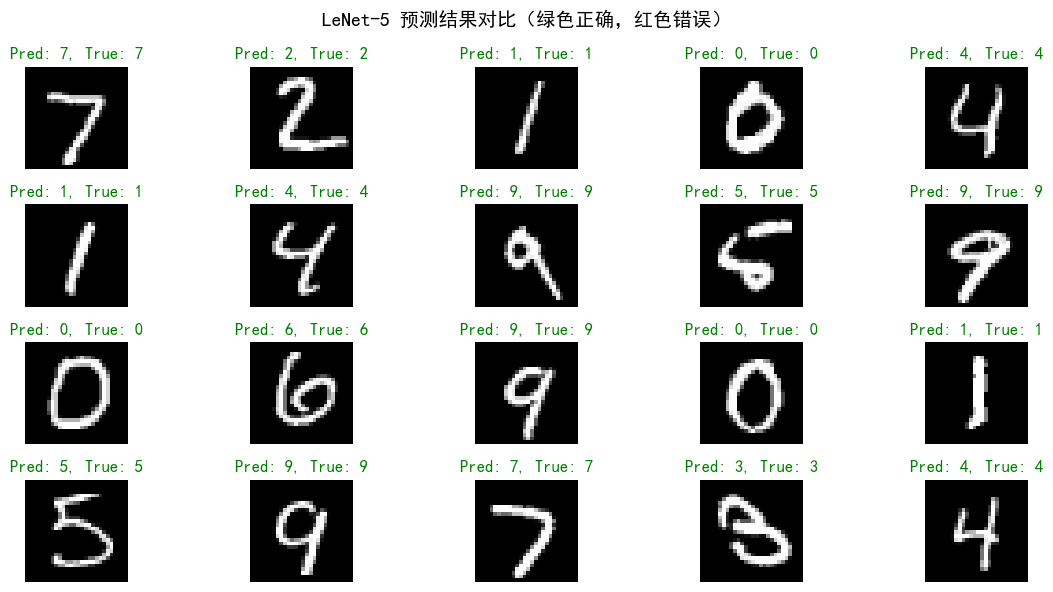

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 选择要显示的样本数量
n_samples = 20
# 从验证集中取样本（X_val 是图像，y_val 是 one-hot 标签）
X_show = X_val[:n_samples]
y_show = y_val[:n_samples]

# 获取预测类别
preds = lenet.predict(X_show)
true_labels = np.argmax(y_show, axis=1)

# 创建画布
fig, axes = plt.subplots(4, 5, figsize=(12, 6))
axes = axes.flatten()

for i in range(n_samples):
    # 显示图像（取第一个通道，灰度）
    axes[i].imshow(X_show[i, :, :, 0], cmap='gray')
    # 设置标题：预测 vs 真实
    title = f"Pred: {preds[i]}, True: {true_labels[i]}"
    axes[i].set_title(title, fontsize=12,
                      color='green' if preds[i] == true_labels[i] else 'red')
    axes[i].axis('off')

plt.suptitle("LeNet-5 预测结果对比（绿色正确，红色错误）", fontsize=14)
plt.tight_layout()
plt.show()